|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">A deep understanding of AI language model mechanisms</a></h1>|
|-|:-:|
|<h2>Part 2:</h2>|<h1>Large language models<h1>|
|<h2>Section:</h2>|<h1>Build a GPT<h1>|
|<h2>Lecture:</h2>|<h1><b>Softmax (and temperature): math, numpy, and pytorch<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/dullms_x/?couponCode=202508" target="_blank">udemy.com/course/dullms_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Implementation in numpy

In [2]:
# the list of numbers
z = [1,2,3]

# compute the softmax result
num = np.exp(z)
den = np.sum( np.exp(z) )
sigma = num / den

print(sigma)
print(np.sum(sigma))

[0.09003057 0.24472847 0.66524096]
1.0


[ 6 -1 -4  0  3  6 12 -3  3 -3 -1  5  8  9  0  9  8 -2 10 -5 12  4  9 11
  9]


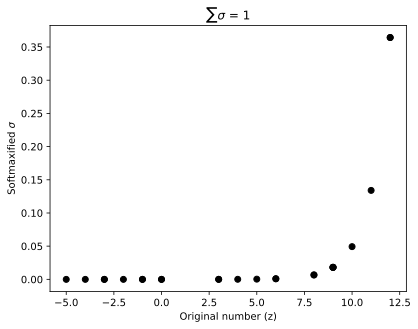

In [3]:
# repeat with some random integers
z = np.random.randint(-5,high=15,size=25)
print(z)

# compute the softmax result
num = np.exp(z)
den = np.sum( num )
sigma = num / den

# compare
plt.plot(z,sigma,'ko')
plt.xlabel('Original number (z)')
plt.ylabel('Softmaxified $\sigma$')
# plt.yscale('log')
plt.title('$\sum\sigma$ = %g' %np.sum(sigma))
plt.show()

# Using pytorch

In [4]:
zTorch = torch.tensor(z,dtype=torch.float64)

# using a function
F.softmax(zTorch)#,dim=-1)

C:\Users\marco\AppData\Local\Temp\ipykernel_29488\2020561211.py:4: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  F.softmax(zTorch)#,dim=-1)


tensor([9.0285e-04, 8.2330e-07, 4.0989e-08, 2.2380e-06, 4.4950e-05, 9.0285e-04,
        3.6424e-01, 1.1142e-07, 4.4950e-05, 1.1142e-07, 8.2330e-07, 3.3214e-04,
        6.6712e-03, 1.8134e-02, 2.2380e-06, 1.8134e-02, 6.6712e-03, 3.0287e-07,
        4.9294e-02, 1.5079e-08, 3.6424e-01, 1.2219e-04, 1.8134e-02, 1.3400e-01,
        1.8134e-02], dtype=torch.float64)

# Adding "temperature"

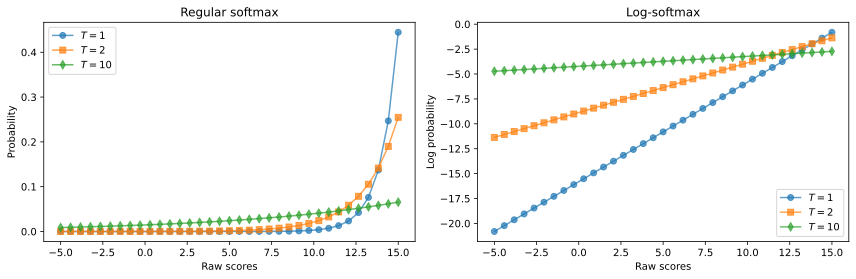

In [5]:
# list of temperatures to use (T = 1/beta)
temperatures = [ 1, 2, 10 ]

rawscores = torch.linspace(-5,15,35)
shapes = 'osd'

_,axs = plt.subplots(1,2,figsize=(12,4))
for temp,s in zip(temperatures,shapes):

  # scale the scores by temperature
  heatedScores = rawscores / temp

  # and plot
  axs[0].plot(rawscores,F.softmax(heatedScores,dim=0),f'{s}-',alpha=.7,label=r'$T=%g$'%temp)
  axs[1].plot(rawscores,F.log_softmax(heatedScores,dim=0),f'{s}-',alpha=.7,label=r'$T=%g$'%temp)


axs[0].legend()
axs[0].set(xlabel='Raw scores', ylabel='Probability',title='Regular softmax')
axs[1].legend()
axs[1].set(xlabel='Raw scores', ylabel='Log probability',title='Log-softmax')

plt.tight_layout()
plt.show()